<a href="https://colab.research.google.com/github/Bushra-3259/Brain-Tumor-MRI-Classification/blob/main/Building_a_Brain_Tumor_Detection_Using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Step: 1

from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


#***Importing Required Libraries***

In [ ]:
#Step: 2

import os
# 'os' is used to interact with the operating system.
# It helps with file paths, folder navigation, and listing directories (useful for loading image datasets).

import numpy as np
# 'numpy' is used for numerical operations, especially with arrays.
# In deep learning, we often represent images and data as numpy arrays for faster computation.

import random
# 'random' is used to generate random numbers or shuffle data.
# It’s helpful when we want to randomly split datasets or apply random transformations.

from PIL import Image, ImageEnhance
# 'PIL' (Python Imaging Library, via Pillow) is used for image manipulation.
# 'Image' helps open, resize, or crop images.
# 'ImageEnhance' is used to adjust brightness, contrast, or color intensity of images.

from tensorflow.keras.preprocessing.image import load_img
# 'load_img' is a convenient Keras function to load an image from disk.
# It can resize images and convert them into a format compatible with neural networks.

from tensorflow.keras.models import Sequential
# 'Sequential' lets you build a neural network model layer by layer in a linear order.
# It’s the simplest way to create models in Keras.

from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
# 'Input' defines the shape of input data to the model.
# 'Flatten' converts multi-dimensional image data (like 3D tensors) into 1D arrays before feeding them to Dense layers.
# 'Dropout' helps prevent overfitting by randomly disabling some neurons during training.
# 'Dense' is a fully connected layer where each neuron connects to all neurons in the previous layer.

from tensorflow.keras.optimizers import Adam
# 'Adam' is a popular optimization algorithm that adjusts learning rates automatically.
# It combines the benefits of SGD + momentum and RMSProp, making training faster and more stable.

from tensorflow.keras.applications import VGG16
# 'VGG16' is a pre-trained deep learning model developed by Oxford’s Visual Geometry Group.
# You can use it as a feature extractor or fine-tune it for your own classification tasks.
# It's already trained on the ImageNet dataset, which helps models learn quickly without starting from scratch.

from sklearn.utils import shuffle
# 'shuffle' is used to randomly shuffle datasets (images and labels together).
# Shuffling helps the model learn more robustly and prevents bias from ordered data.

#***Load Datasets***

In [ ]:
#Step: 3

# This is where your image dataset is stored inside Google Drive.
# '/content/drive/MyDrive/MRI Images/Training' → training images
# '/content/drive/MyDrive/MRI Images/Testing' → testing images
train_dir = '/content/drive/MyDrive/MRI Images/Training'
test_dir = '/content/drive/MyDrive/MRI Images/Testing'

# We'll store the full file paths of all training images here.
train_paths = []

# We'll store the corresponding class labels (folder names) here.
train_labels = []

# os.listdir(train_dir) → lists all the folders inside Training
# Each folder represents one class (for example: 'Tumor', 'Normal', etc.)
for label in os.listdir(train_dir):

  # os.path.join(train_dir, label) → gives the full path to that class folder
  # os.listdir(...) → lists all image filenames inside that class folder
  for image in os.listdir(os.path.join(train_dir, label)):

    # Append the full image path (e.g., '/content/drive/.../Training/Tumor/img1.jpg')
    train_paths.append(os.path.join(train_dir, label, image))

    train_labels.append(label) # Append the class name (e.g., 'Tumor')

# This will show the full list of all image paths used for training
train_paths, train_labels = shuffle(train_paths, train_labels)

# Similarly, create lists for testing data paths and labels
test_paths = []
test_labels = []

# Loop through each class folder inside Testing directory
for label in os.listdir(test_dir):

  # Loop through each image inside that class folder
  for image in os.listdir(os.path.join(test_dir, label)):

    # Append the full path of the image file
    test_paths.append(os.path.join(test_dir, label, image))

    test_labels.append(label) # Append the label name (folder name)

test_paths, test_labels = shuffle (test_paths, test_labels) # Display all the testing image paths


#***Data Visualization***

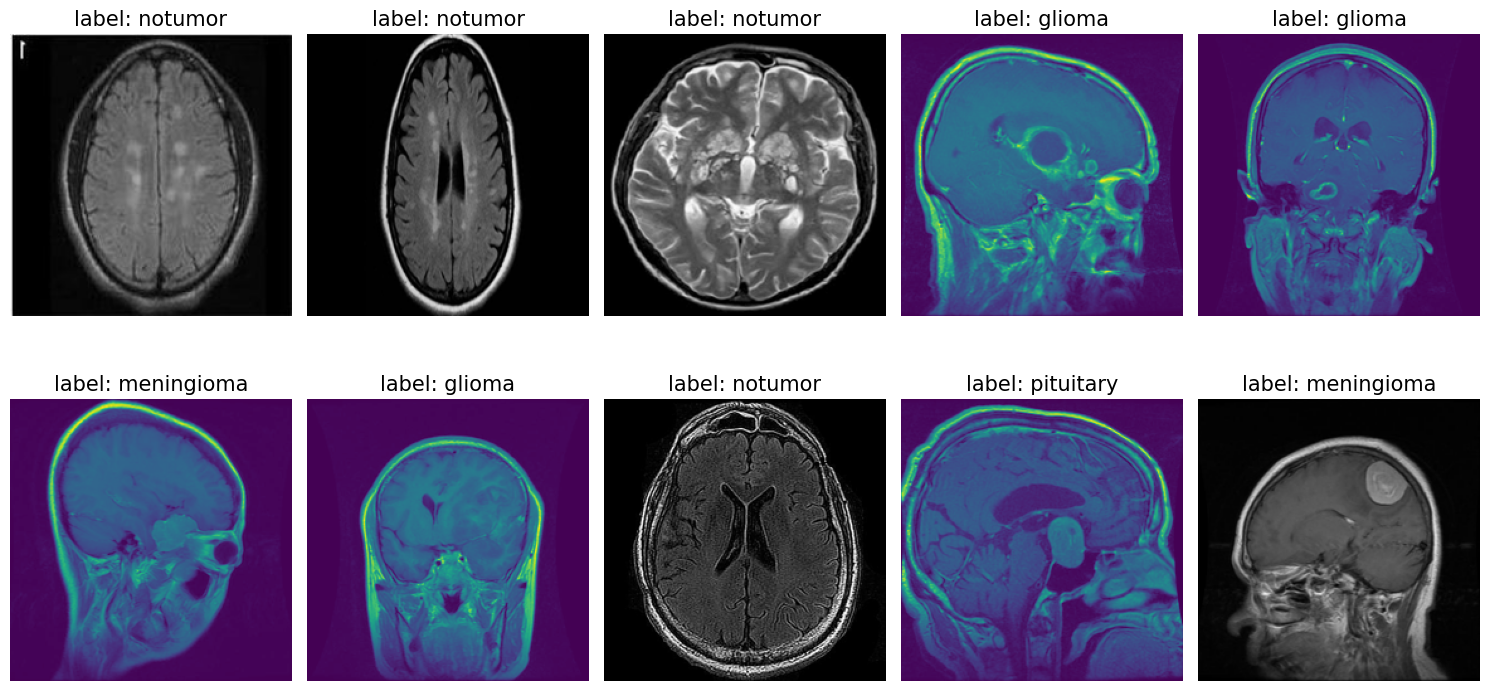

In [ ]:
#Step: 4

import random
import matplotlib.pyplot as plt
# 'matplotlib.pyplot' (plt) is a plotting library used for data visualization.
# We will use it to create a grid of subplots and display MRI images.

# Select 10 random indices from the list 'train_paths'
# 'train_paths' is a list of file paths for your training MRI images.
# 'range(len(train_paths))' creates a sequence of numbers from 0 to (number of images - 1).
# 'random.sample(..., 10)' picks 10 UNIQUE random indices—no duplicates.
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure with 2 rows and 5 columns to display 10 images total
# 'figsize=(15,6)' sets the size of the whole image grid.
fig, axes = plt.subplots(2, 5, figsize=(15, 8))

# 'axes' is a 2D array by default (2 rows × 5 columns).
# '.ravel()' flattens it into a 1D list of 10 axes.
# This makes indexing easier when looping (axes[0], axes[1], ..., axes[9]).
axes = axes.ravel()

# Loop through the randomly selected indices
# 'enumerate' gives us both:
#    - i  → loop counter (0 to 9)
#    - idx → the actual random index from 'random_indices'
for i, idx in enumerate(random_indices): #i → the counter (0, 1, 2, 3, …). idx → the actual element from the list
    img_path = train_paths[idx] # Get the full file path of the image using the index
    img = Image.open(img_path)  # Open the image file located at 'img_path' using PIL's Image.open
    img = img.resize((224, 224)) #width, height

    #display images
    axes[i].imshow(img) # Display the image in the corresponding subplot (axes[i])
    axes[i].axis("off")  # Remove axis ticks and labels for a cleaner display
    axes[i].set_title(f"label: {train_labels[idx]}", fontsize=15) # Set a title above the i-th subplot (image), f"label: {train_labels[idx]}" → creates a string showing the label of this image, train_labels[idx] → gets the actual label (e.g., "cat", "dog") for this image.

plt.tight_layout() # Adjust the spacing between subplots so they don't overlap
plt.show() # Finally, render the figure with all images displayed


#**Image Preprocessing (Helper Functions)**

In [ ]:
# Step: 5

# Updated Helper Functions

def augment_image(image):
    # Ensure input is a PIL Image
    if not isinstance(image, Image.Image):
        image = Image.fromarray(np.uint8(image))

    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))

    # Normalize to [0, 1] range
    return np.array(image) / 255.0

def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

def encoded_label(labels):
    # Sort class names to ensure consistent label encoding across sessions
    unique_labels = sorted(os.listdir(train_dir))
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i+batch_size]
            batch_images = open_images(batch_paths)

            batch_labels = labels[i:i+batch_size]
            batch_labels = encoded_label(batch_labels)

            yield batch_images, batch_labels

#**MODEL:**
**WE ARE USING VGG16 FOR TRANSFER LEARNING.**
*The model is built on top of VGG16, which is a pre-trained convolutional neural network (CNN) for image classification.*

* First, the VGG16 model is loaded with input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), include_top=False, weights='imagenet'. The input shape is set to match the size of the images in the dataset, which is 128x128 pixels. The include_top parameter is set to False, which means that the final fully-connected layers of VGG16 that perform the classification will not be included. The weights parameter is set to 'imagenet' which means that the model will be pre-trained with a dataset of 1.4 million images called imagenet.

* Next, the for layer in base_model.layers: loop is used to set all layers of the base_model (VGG16) to non-trainable, so that the weights of these layers will not be updated during training.

* Then, the last three layers of the VGG16 model are set to trainable by using base_model.layers[-2].trainable = True,base_model.layers[-3].trainable = True and base_model.layers[-4].trainable = True

* After that, a Sequential model is created and the VGG16 model is added to it with model.add(base_model).

* Next, a Flatten layer is added to the model with model.add(Flatten()) which reshapes the output of the VGG16 model from a 3D tensor to a 1D tensor, so that it can be processed by the next layers of the model.

* Then, a Dropout layer is added with model.add(Dropout(0.3)) which is used to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time.

* After that, a dense layer is added with 128 neurons and relu activation function is added with model.add(Dense(128, activation='relu')).

* Next, another Dropout layer is added with model.add(Dropout(0.2))

* Finally, the output dense layer is added with number of neurons equal to the
number of unique labels and 'softmax' activation function is added with model.add(Dense(len(unique_labels), activation='softmax')). The 'softmax' activation function is used to give a probability distribution over the possible classes.

In [ ]:
#Step: 6

# VGG16 is a famous 16-layer CNN deep learning model, widely used in computer vision for image classification, feature extraction, and transfer learning.
#It's a pre-trained model with large no. of parameters (weights) learned from ImageNet, which contains millions of images and 1000 classes.
# Using it, you can leverage these learned features for your own tasks without training a network from scratch.

#Model architecture
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet') # width, height, 3 color channels (RGB), avoid top layers (we will do our own custom-made), and whatever weights (knowledge) used in imagenet we'll use that since that quite excellent.

# Freeze all layers initially so their weights won't be updated during training
# This is useful to retain the pre-trained knowledge and reduce training time
# VGG16’s early layers already know basic features (edges, lines, corners, textures) from ImageNet.
# By freezing these layers, we preserve this knowledge, avoid overwriting it with small datasets, and speed up training, since only the unfrozen layers are updated.
for layer in base_model.layers:
  layer.trainable = False

# Unfreeze the last few layers so they can be trained on your dataset
# You can choose how many layers to unfreeze depending on how much customization you want
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model) # VGG16 model. The output will be multidimensional, but let's say we need 1D.
model.add(Flatten()) # Flatten layer to get 1D. Sometimes cause overfitting because Flatten creates a large number
# of parameters. Overfitting is when a model learns too much from the training data — not just the patterns, but also the noise, mistakes, and random details.
model.add(Dropout(0.3)) # Dropout layer: helps prevent overfitting by randomly turning off 30% of neurons during training. This forces the model to learn more robust, general features.

model.add(Dense(128, activation='relu')) # Dense layer: a fully connected layer (not the final output layer). ReLU stands for Rectified Linear Unit. Keeps only the positive values and turns all negative values into 0. Again, may cause overfitting.
model.add(Dropout(0.2))

model.add(Dense(len(os.listdir(train_dir)), activation="softmax")) # Output layer. Activation is softmax for multi-class classification, sigmoid for binary classification (yes/no, 0/1), relu that turns negative values into 0 & Keeps positive values. Other activation are also there.

# Compile the model.
model.compile(optimizer= Adam (learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics = ['sparse_categorical_accuracy']) #  loss function used for multi-class classification problems where: you have more than 2 classes (e.g., classifying images into cats, dogs, birds) and the target labels are integers (0, 1, 2, 3, ...) rather than one-hot encoded vectors.
#We know inside DL, we have NN where a propgation is there which updates your weights on basis of learning rate.

#Now we will train the model.
# 1stly we set some parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5 # train your model for 5 epochs (times). One epoch = One complete pass through your entire training dataset.

#Now we train the model
history = model.fit ( datagen(train_paths, train_labels, batch_size = batch_size, epochs=epochs),
    epochs=epochs, steps_per_epoch=steps) # datagen is Your made up data generator that yields batches of data. steps_per_epoch: How many batches constitute one epoch

# complete the step: 5 (all functions have been used with "pass" only)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1436s 5s/step - loss: 0.4738 - sparse_categorical_accuracy: 0.8211
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1388s 5s/step - loss: 0.2286 - sparse_categorical_accuracy: 0.9113
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1388s 5s/step - loss: 0.1388 - sparse_categorical_accuracy: 0.9489
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1387s 5s/step - loss: 0.1058 - sparse_categorical_accuracy: 0.9598
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1389s 5s/step - loss: 0.0774 - sparse_categorical_accuracy: 0.9717


#**Train and Val Plots**

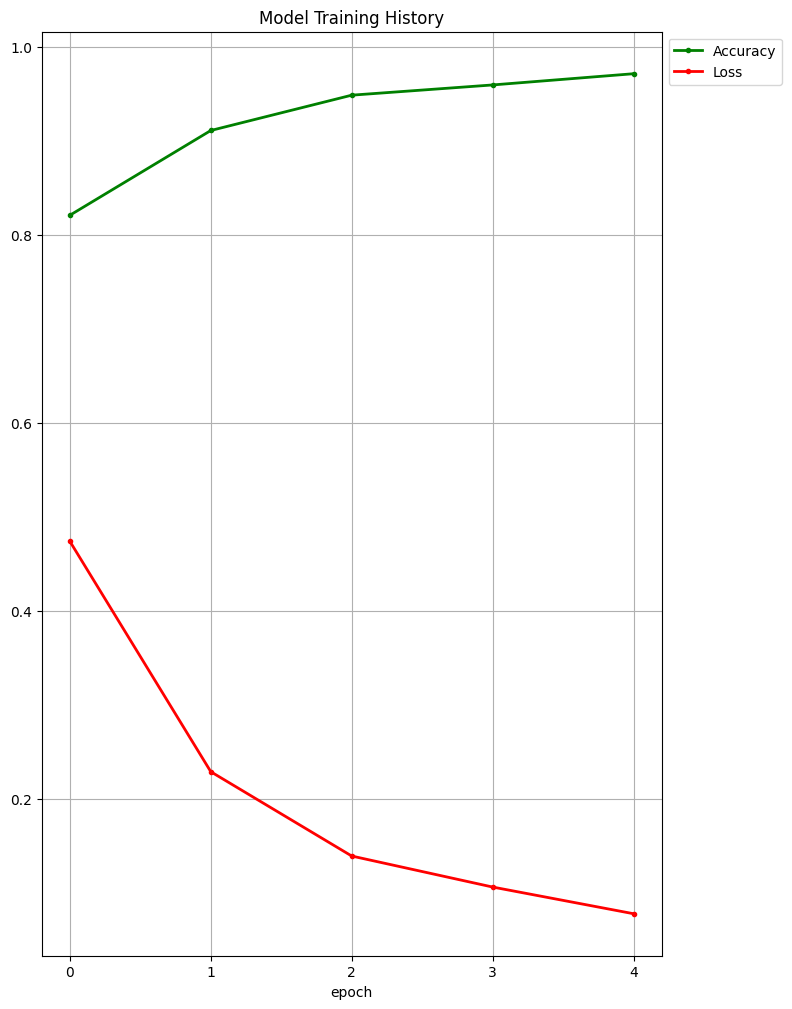

In [ ]:
#Step: 7

plt.figure(figsize=(8, 12)) # width8, height = 12
plt.grid(True) # add grids

# Plot training accuracy over epochs
# history.history['sparse_categorical_accuracy'] → list of accuracy values for each epoch
# The first history = the object returned by model.fit()
# The second history = a dictionary inside that object where all metrics are stored
# '.g-' → g = green color, '.' = show point markers, '-' = line
# linewidth=2 → thickness of the line
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)

# Plot training loss over epochs
# history.history['loss'] → list of loss values for each epoch
# '.r-' → r = red color, point markers with line
plt.plot(history.history['loss'], '.r-', linewidth=2) # we go to history where we call the function history, and call loss which we see above after installing, then apply the red color for the slop line whose width is 2
plt.title('Model Training History')
plt.xlabel('epoch')

# Set x-axis ticks as 0,1,2,3,... up to number of epochs
# (we use a list comprehension to generate numbers from 0 to epochs-1)
plt.xticks([x for x in range(epochs)])

# Add a legend to identify which line is accuracy and which is loss
# loc='upper left' → start placing legend from top-left corner
# bbox_to_anchor=(1,1) → push the legend outside the graph for cleanliness
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1,1))
plt.show()

#**Model Classification Report**

In [ ]:
#Step: 8

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
# classification_report → gives precision, recall, f1-score, accuracy for each class
# confusion_matrix → shows actual vs predicted labels in a matrix
# roc_curve → computes points for ROC curve
# auc → calculates area under ROC curve

import matplotlib.pyplot as plt
import seaborn as sns  # For prettier plots, e.g., heatmaps
from sklearn.preprocessing import label_binarize # Converts labels to one-hot format
from tensorflow.keras.models import load_model
import numpy as np

# Load test images using a custom function 'open_images'
# test_paths → list of file paths for test images
test_images = open_images(test_paths)

# Encode test labels using a custom function 'encoded_label'
# Converts textual labels to numeric labels (e.g., "cat" → 0, "dog" → 1)
test_labels_encoded = encoded_label(test_labels)

# prediction using model
test_predictions = model.predict(test_images)

print("Classification Report: ")

# np.argmax(test_predictions, axis=1) → converts predicted probabilities to class labels
# For example: [0.1, 0.8, 0.1] → 1 (because max probability is at index 1)
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 264s 6s/step
Classification Report: 
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       300
           1       0.98      0.84      0.90       306
           2       0.96      1.00      0.98       405
           3       1.00      0.98      0.99       300

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.95      0.95      0.95      1311



#**Model Confusion Plot**

Confusion Matrix: 


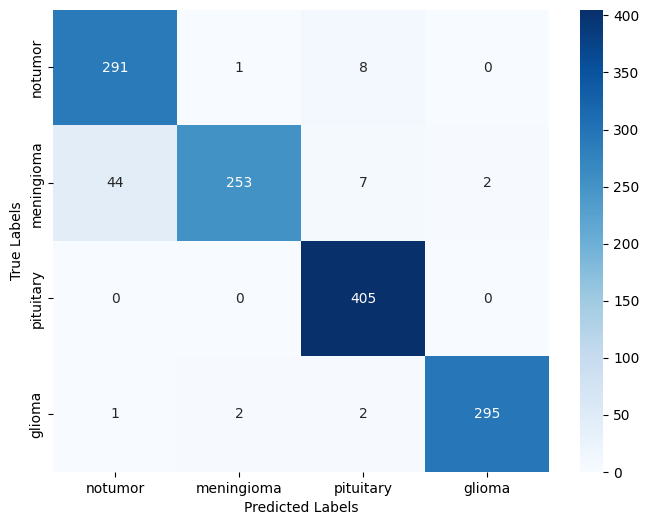

In [ ]:
#Step: 9

conf_matrix = confusion_matrix(test_labels_encoded, np.argmax (test_predictions, axis=1))
# np.argmax(test_predictions, axis=1) converts model probabilities → predicted class numbers

plt.figure(figsize=(8,6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
# Plot confusion matrix using seaborn heatmap, annot->show numbers, fmt->format as integers, cmap->blue color map, predicted labels, true labels
# A heatmap is a visual way of showing numbers using colors instead of plain text. High numbers → darker / stronger colors. Low numbers → lighter colors. So instead of reading boring numbers in a table, your brain instantly sees the pattern.

print("Confusion Matrix: ")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#**Roc Curve Plot**

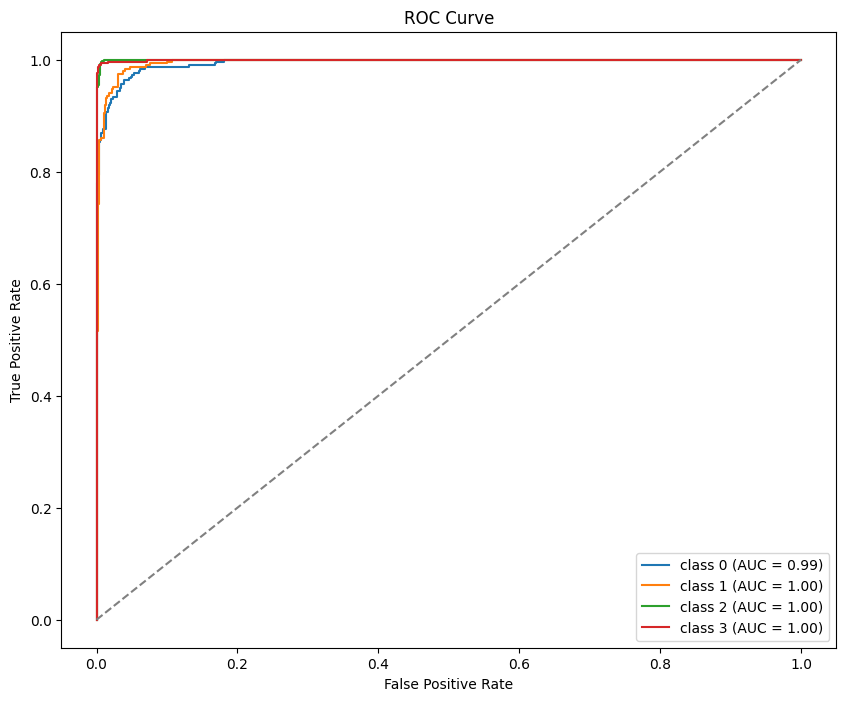

In [ ]:
#Step: 10

# ROC curve needs binary values for each class.

# Binarize the test labels & predictions for multi-class ROC
# For ROC curve in multi-class classification, we need labels in "one-hot" form.
# Example:
# Class 0 → [1, 0, 0]
# Class 1 → [0, 1, 0]
# Class 2 → [0, 0, 1]
# This converts integer class labels into binary vectors for each class.
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir)))) # np.arange(n) → generates numbers from 0 to n-1. np.arrange(n) → does not exist.
test_predictions_bin = test_predictions

# Compute ROC curve and ROC AUC for each class
# We create 3 dictionaries to store:
# fpr = False Positive Rate for each class
# tpr = True Positive Rate for each class
# roc_auc = Area Under the Curve (AUC) for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range((len(os.listdir(train_dir)))):
  # roc_curve requires:
    # 1) true binary labels for class i → test_labels_bin[:, i]
    # 2) predicted probabilities for class i → test_predictions_bin[:, i]
  fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i]) # [:, i]->Take all rows, but only column i. Eg: test_labels_bin[:, 0] → all rows, column 0.
  roc_auc[i] = auc(fpr[i], tpr[i]) # auc() calculates the Area Under the ROC Curve

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))): # Plot ROC curve for each class separately
  plt.plot(fpr[i], tpr[i], label=f'class {i} (AUC = {roc_auc[i]:.2f})') # roc_auc[i]:.2f is just formatting — it controls how the number looks when printed.
  # .2f->2 decimal places

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# curve above the slope -> best results, and vice versa

#**Save & Load Model**

In [ ]:
#Step: 11

# Save the entire model
model.save('model.h5') # Saves your entire trained deep learning model into a file named model.h5
# This file contains:
# Model architecture (which layers, what settings, shapes, etc.)
# Model weights (all learned parameters from training)
# Optimizer state (so you can resume training later if you want)
# This means you can close Colab, shut down everything, come back tomorrow, load it again, and it will work exactly as before.

In [ ]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

#**MRI Tumor Detection System**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step


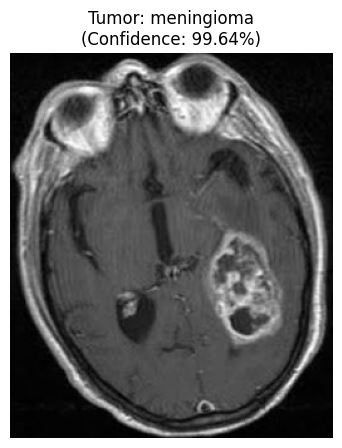

In [ ]:
#Step: 12

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Dynamically derive sorted class labels matching the encoder step
class_labels = sorted(os.listdir(train_dir))

def detect_and_display(image_path, model):
    try:
        # Load and resize image
        img = load_img(image_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img_array = img_to_array(img)

        # Scale inputs to match training preprocessing ([0, 1])
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Run inference
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions)
        confidence_score = np.max(predictions)

        predicted_label = class_labels[predicted_class_index]

        if predicted_label.lower() in ['notumor', 'no_tumor']:
            result = "No Tumor Detected"
        else:
            result = f"Tumor: {predicted_label}"

        # Display image and prediction details
        plt.figure(figsize=(5, 5))
        plt.imshow(load_img(image_path))
        plt.axis('off')
        plt.title(f"{result}\n(Confidence: {confidence_score * 100:.2f}%)", fontsize=12)
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-meTr_0001.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step


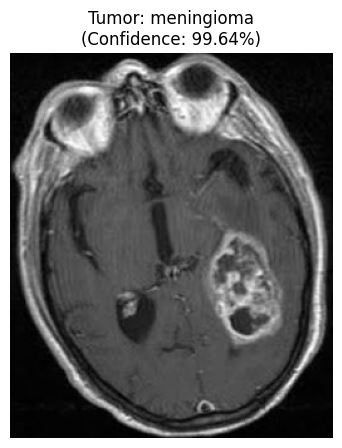

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-meTr_0001.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step


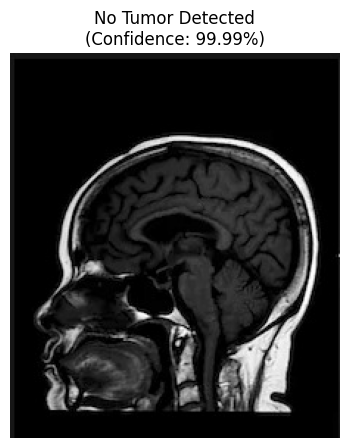

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-noTr_0004.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


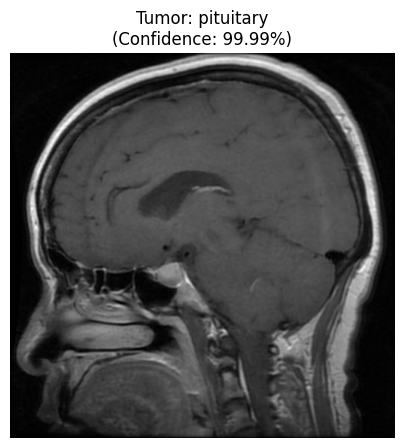

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-piTr_0003.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


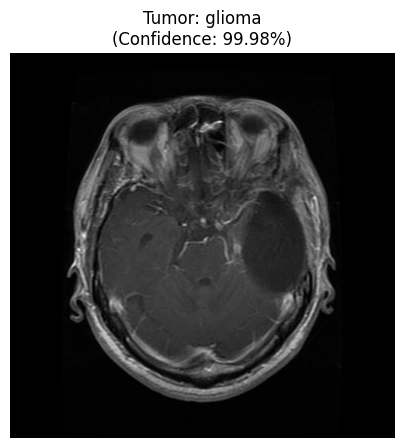

In [ ]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0015.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

#**Download the model**

In [ ]:
# Run this in a new cell at the bottom of Colab
from google.colab import files

# Save the model variable we created in Step 6
model.save('model.h5')

# Download it to your computer
files.download('model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>